# 07 — End-to-End Case Study

The research reproduction of the demonstration: two real fields, two very different
outcomes, one identical code path.

| | |
|---|---|
| **Case 1 — Niger Delta** | the evidence supports the claim |
| **Case 2 — Permian Basin** | the evidence cannot decide, and two instruments disagree |

Nothing about either case is special-cased. Both run through the same `GreenTruth.analyze`
the application calls, against the same real observations.

The point of running them side by side is to show the system is not wired to agree.

| Notebook card | |
|---|---|
| **Type** | Analyse (no training) |
| **Purpose** | Reproduce the two demo cases (Niger Delta, Permian Basin) through the exact code path the application uses. |
| **Inputs** | The `greentruth` package and `data/real/`. |
| **Outputs** | `evaluation/07_case_study.json`. |
| **Where it runs** | Locally from a checkout, or Colab with the project folder available. |
| **Execution record** | Executed locally against the final code — record in `notebooks/executed/07_end_to_end_case_study.ipynb`. |


## 0. Setup

In [1]:
# ---------------------------------------------------------------- setup
# This notebook needs the GreenTruth package and the real data in data/real/.
# Nothing is uploaded by hand: if the repo is not present, the public flaring
# data is downloaded directly from the World Bank.
import os, sys, json, glob
from pathlib import Path

CANDIDATES = [".", "..", "/content", "/content/greentruth",
              "/content/drive/MyDrive/greentruth"]
REPO = None
for c in CANDIDATES:
    if os.path.isdir(os.path.join(c, "greentruth")):
        REPO = os.path.abspath(c)
        if REPO not in sys.path:
            sys.path.insert(0, REPO)
        break

if REPO is None:
    raise SystemExit(
        "GreenTruth package not found.\n"
        "Make it importable by ONE of:\n"
        "  * Colab Files panel -> upload the project folder\n"
        "  * from google.colab import drive; drive.mount('/content/drive')\n"
        "    with the project at /content/drive/MyDrive/greentruth\n"
        "  * run this notebook from inside a local checkout")

os.chdir(REPO)
print("repo:", REPO)

REAL = Path(REPO) / "data" / "real" / "flaring_by_field.csv"
if not REAL.exists():
    print("\ndata/real/flaring_by_field.csv missing -> run notebook 03 first.")
    print("It downloads the public World Bank release directly (no account).")
    raise SystemExit("real data not present")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from greentruth import GreenTruth

gt = GreenTruth(detector_preference="rule_based")
cov = gt.evidence.coverage()
print(f"\nreal evidence : {cov['n_observations']} annual observations, "
      f"{cov['n_fields']} fields, {cov['year_min']}-{cov['year_max']}")
print(f"methane       : {'loaded' if gt.methane.available else 'not loaded'}")
print(f"detector      : {gt.detector_info['detector']}"
      f"{' (fallback)' if gt.detector_info.get('fallback') else ''}")

repo: <local checkout>



real evidence : 156 annual observations, 12 fields, 2012-2024
methane       : loaded
detector      : rule_based (fallback)


In [2]:
# ------------------------------------------------- data provenance banner
# Printed before any analysis so a reader can see exactly what is loaded,
# where it came from, and under what licence — without leaving the notebook.
reg_path = Path(REPO) / "data" / "dataset_registry.json"
if reg_path.exists():
    reg = json.loads(reg_path.read_text(encoding="utf-8"))
    print("=" * 78)
    print("DATA PROVENANCE")
    print("=" * 78)
    for d in reg["datasets"]:
        ff = d.get("file_facts") or {}
        if not ff.get("present") and not d.get("n_test"):
            continue
        if d.get("role_in_greentruth") == "NOT USED":
            continue
        print(f"\nDATA SOURCE   {d['name']}")
        print(f"PROVIDER      {d['provider']}")
        print(f"INSTRUMENT    {d['instrument']}")
        print(f"URL           {d['official_url']}")
        print(f"LICENSE       {d['licence']}")
        print(f"RESOLUTION    {d['spatial_resolution']} | {d['temporal_resolution']}")
        if ff.get("present"):
            print(f"DATA SHAPE    {ff['rows']:,} rows x {len(ff['columns'])} cols "
                  f"| {ff['entities']} entities | {ff['year_min']}-{ff['year_max']}")
        elif d.get("n_test"):
            print(f"DATA SHAPE    test split n = {d['n_test']}")
        print(f"DATE ACCESSED {d['date_accessed']}  ({d['date_accessed_note']})")
        print(f"ROLE          {d['role_in_greentruth']}")
    print("\n" + "=" * 78)
    print(reg["independence_rule"])
    print("=" * 78)
else:
    print("data/dataset_registry.json not found — run "
          "scripts/build_dataset_registry.py to generate it.")

DATA PROVENANCE

DATA SOURCE   World Bank Global Gas Flaring Tracker — individual flare locations
PROVIDER      World Bank, Global Flaring and Methane Reduction (GFMR) Partnership
INSTRUMENT    VIIRS (Suomi-NPP / NOAA-20)
URL           https://www.worldbank.org/en/programs/gasflaringreduction/global-flaring-data
LICENSE       Published publicly by the World Bank. Check the portal terms before redistribution; this project does not commit the CSVs.
RESOLUTION    Individual flare detections; aggregated here to named fields by a per-field match radius (60–200 km) | annual
DATA SHAPE    156 rows x 4 cols | 12 entities | 2012-2024
DATE ACCESSED 2026-09-17  (local file timestamp, a proxy for when the pipeline notebook was run)
ROLE          PRIMARY EVIDENCE for gas-flaring claims

DATA SOURCE   World Bank Global Gas Flaring Tracker — country totals
PROVIDER      World Bank, Global Flaring and Methane Reduction (GFMR) Partnership
INSTRUMENT    VIIRS (Suomi-NPP / NOAA-20)
URL           https://

## 1. The two cases

In [3]:
CASES = [
    dict(id="case1", title="Evidence supports the claim", field="Niger Delta",
         text="We reduced routine gas flaring by 40% by 2023 from 2012 levels."),
    dict(id="case2", title="Evidence cannot decide; instruments disagree",
         field="Permian Basin",
         text="We reduced routine gas flaring by 25% from 2019 levels."),
]

results = {}
for case in CASES:
    r = gt.analyze(case["text"], case["field"])
    results[case["id"]] = (case, r)
    c_ = r["claims"][0]; a = c_["analysis"]; s = c_["sufficiency"]
    sy = c_.get("synthesis") or {}
    print("=" * 78)
    print(f"{case['title'].upper()}  —  {case['field']}")
    print("=" * 78)
    print(f'  claim      "{case["text"]}"')
    print(f"  observed   {a['observed_change']*100:+.0f}%   claimed "
          f"{a['claimed_change']*100:+.0f}%")
    print(f"  90% interval [{a['interval'][0]*100:+.0f}%, {a['interval'][1]*100:+.0f}%]"
          f"   regions spanned: {a['region_span']}")
    print(f"  VERDICT    {c_['verdict_label'].upper()}")
    print(f"  suffic.    {s['level']}  ->  {s['evidence_ceiling']}")
    print(f"  synthesis  {sy.get('label')}")
    m = c_.get("methane") or {}
    if m.get("available"):
        print(f"  methane    anomaly {m['anomaly_change_ppb']:+.1f} ppb "
              f"(raw {m['methane_change_ppb_raw']:+.1f}, background "
              f"{m['background_change_ppb']:+.1f})  -> {m['relationship']}")
    else:
        print(f"  methane    unavailable — {m.get('detail','')[:90]}")
    print()

EVIDENCE SUPPORTS THE CLAIM  —  Niger Delta
  claim      "We reduced routine gas flaring by 40% by 2023 from 2012 levels."
  observed   -42%   claimed -40%
  90% interval [-44%, -13%]   regions spanned: 1
  VERDICT    SUPPORTED
  suffic.    PARTIALLY_SUFFICIENT  ->  Single-instrument consistency only: the result is not corroborated by a different sensor.
  synthesis  Sources agree
  methane    unavailable — TROPOMI retrieved usable methane for only 24% of the possible months at Niger Delta — too 

EVIDENCE CANNOT DECIDE; INSTRUMENTS DISAGREE  —  Permian Basin
  claim      "We reduced routine gas flaring by 25% from 2019 levels."
  observed   -29%   claimed -25%
  90% interval [-25%, +127%]   regions spanned: 2
  VERDICT    ABSTAIN / UNCERTAIN
  suffic.    INSUFFICIENT  ->  No conclusion can be drawn from the available observations.
  synthesis  Cross-sensor tension
  methane    anomaly +12.1 ppb (raw +52.5, background +40.4)  -> flaring_down_methane_up



## 2. Side-by-side trajectories

Same axes, same styling rules: solid is observed, dashed is what the claim implies, the
shaded band is the 90% interval on the observed change.

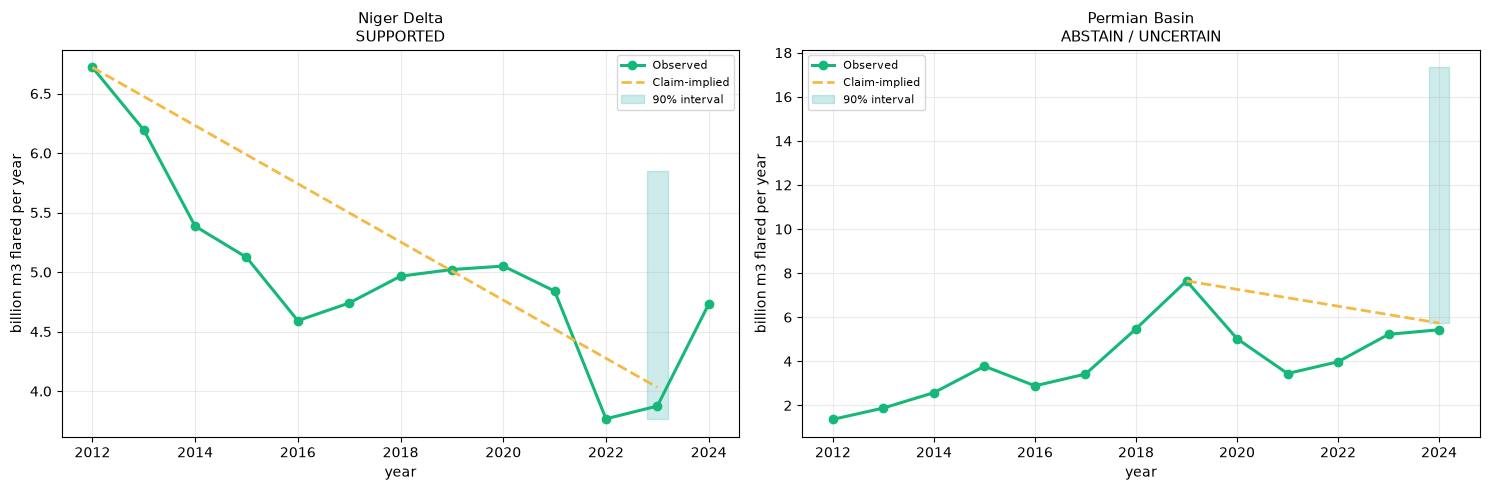

Case 1's interval stays inside one decision region, so a verdict is stated.
Case 2's interval spans reduction AND increase, so the system abstains —
even though its point estimate looks like a clear success.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, (cid, (case, r)) in zip(axes, results.items()):
    c_ = r["claims"][0]; a = c_["analysis"]; ev = c_["evidence"]
    ax.plot(ev["years"], ev["values"], "o-", color="#15b879", lw=2.2, label="Observed")
    b, e = a["baseline_year"], a["comparison_year"]
    bv = a["baseline_value"]; implied = bv * (1 + a["claimed_change"])
    ax.plot([b, e], [bv, implied], "--", color="#f4b942", lw=2, label="Claim-implied")
    lo, hi = a["interval"]
    ax.fill_between([e - 0.2, e + 0.2], bv * (1 + lo), bv * (1 + hi),
                    color="#1ea5a1", alpha=.22, label="90% interval")
    ax.set_title(f"{case['field']}\n{c_['verdict_label'].upper()}", fontsize=11)
    ax.set_xlabel("year"); ax.set_ylabel(ev["unit"]); ax.grid(alpha=.25)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Case 1's interval stays inside one decision region, so a verdict is stated.")
print("Case 2's interval spans reduction AND increase, so the system abstains —")
print("even though its point estimate looks like a clear success.")

## 3. Sufficiency checklists, side by side

In [5]:
for cid, (case, r) in results.items():
    s = r["claims"][0]["sufficiency"]
    print(f"\n{case['field']}  ->  {s['level']}")
    for chk in s["checks"]:
        print(f"   {chk['symbol']} {chk['label']}")
        if chk["status"] != "pass":
            print(f"       {chk['detail'][:130]}")


Niger Delta  ->  PARTIALLY_SUFFICIENT
   ✓ Claim metric identified
   ✓ Observation channel available
   ✓ Facility identified
   ✓ Observations available
   ✓ Claim period covered by observations
   ✓ Enough observations for a trend
   ⚠ Attribution to the claiming organisation
       VIIRS detects flares at a location. Flaring near a field is consistent with activity there, but it is not proof that a particular 
   ✓ Uncertainty small enough to decide
   ⚠ Cross-scale corroboration (same instrument)
       Between 2012 and 2023, Niger Delta changed by -42% and Nigeria as a whole by -40%. The two scales move together, so the field-leve
   ⚠ Independent instrument (Sentinel-5P methane)
       TROPOMI retrieved usable methane for only 24% of the possible months at Niger Delta — too sparse to read a trend. Retrievals fail 

Permian Basin  ->  INSUFFICIENT
   ✓ Claim metric identified
   ✓ Observation channel available
   ✓ Facility identified
   ✓ Observations available
   ✓ Claim perio

## 4. Save

In [6]:
outdir = Path(REPO) / "evaluation"; outdir.mkdir(exist_ok=True)
payload = {}
for cid, (case, r) in results.items():
    c_ = r["claims"][0]
    payload[cid] = dict(
        title=case["title"], field=case["field"], claim_text=case["text"],
        verdict=c_["verdict"], verdict_label=c_["verdict_label"],
        analysis=c_["analysis"],
        sufficiency_level=c_["sufficiency"]["level"],
        evidence_ceiling=c_["sufficiency"]["evidence_ceiling"],
        synthesis_state=(c_.get("synthesis") or {}).get("state"),
        methane_relationship=(c_.get("methane") or {}).get("relationship"),
        interval_calibration=c_.get("interval_calibration"))
(outdir / "07_case_study.json").write_text(json.dumps(payload, indent=2, default=str))
print("saved -> evaluation/07_case_study.json")
print()
print("GreenTruth does not decide whether an organisation is good or bad.")
print("It shows what the available physical evidence can actually support.")

saved -> evaluation/07_case_study.json

GreenTruth does not decide whether an organisation is good or bad.
It shows what the available physical evidence can actually support.
